# Activity: Let's Benchmark a Bubble Sort Implementation
This example will familiarize students with using benchmarking tools to profile their code's time and space complexity. 

> __Optimization rule of thumb__: Make it run correctly first, then make it run fast! We'll test a bubble sort implementation, which is a well-known sorting algorithm. Once we have verified that it works correctly, we can then focus on measuring its performance.

In this notebook, we'll implement the classic bubble sort algorithm from scratch, verify that it works correctly using unit tests, and then systematically benchmark its performance against Julia's built-in sorting function. 

Through this process, you'll learn essential skills for performance analysis, including how to use Julia's benchmarking tools, interpret timing results, and understand the practical implications of algorithmic complexity. We'll also explore why bubble sort, despite being conceptually simple, is rarely used in practice for large datasets.

So let's get started!

___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

The [include command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

In [1]:
include("Include.jl");

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types and data used in this material. 

### Bubble Sort Implementation
Bubble sort is a simple method of ordering a list. It involves repeatedly passing through the list, comparing adjacent items, and swapping any two neighboring items that are out of order. The algorithm gets its name because smaller elements "bubble" to the top of the list, just like how air bubbles rise to the surface of water.

Let's look at some pseudo-code for our bubble sort implementation:

__Initialization:__ The algorithm starts with an unsorted list of elements in the vector $\mathbf{a}$. Make a copy of the array to avoid modifying the original input. Compute the length of the list $N \gets \texttt{length}(a)$.

__Main sorting loop:__ For each pass $i$ from $1$ to $N$ __do__:
* For each position $j$ from $1$ to $N-i$ __do__:
    * If $a_{j} > a_{j+1}$ __then__:
        * Call the $\texttt{swap}(a_{j}, a_{j+1})$ method to swap (exchange) the two elements.

The key insight here is that after each complete pass through the array (each iteration of the outer loop), the largest element in the unsorted portion will have "bubbled up" to its correct position at the end. That's why we can reduce the inner loop range by $i$ each time - we know the last $i$ elements are already in their final sorted positions.

The $\texttt{swap}(a_{j}, a_{j+1})$ method does the following:

__Implementation:__ Given two elements at positions $j$ and $j+1$ in the array, we swap them using a temporary variable:
1. Set a temporary variable $\texttt{tmp} \gets a_{j}$.
2. Set $a_{j} \gets a_{j+1}$.
3. Set $a_{j+1} \gets \texttt{tmp}$.

This approach is straightforward and matches exactly what our implementation does - no flags or while loops needed, just two simple nested for loops that systematically compare and swap adjacent elements until everything is in order.

Let's develop an implementation of the swap and bubble sort methods:

In [2]:
function _swap!(array::Array{T,1}, i::Int, j::Int) where T <: Number
    tmp = array[i]
    array[i] = array[j]
    array[j] = tmp
end

function bubblesort(array::Array{T,1})::Array{T,1} where T <: Number

    # initialize -
    arr = copy(array) # make a copy of the array
    N = length(arr) # how many elements in the array?

    # main -
    for i ∈ 1:N        
        for j ∈ 1:N-i
            if arr[j] > arr[j+1]

                # TODO: swap that values at j and j+1
                # throw("The bubble_sort function is not implemented yet.");
                _swap!(arr, j, j+1) #
            end
        end
    end

    # return sorted array -
    return arr
end;

___

## Task 1: Test our Bubble Sort Implementation
In this task, we will establish that our bubble sort implementation works correctly. This is a critical step before we can benchmark the performance of any algorithm.

> __Idea__: Let's generate random numerical vectors and compare the sorted output from our bubble sort implementation to the output from the built-in Julia `sort` function. If they match, we can be confident that our bubble sort implementation is correct.

There are a couple of ways to do this tes, one is to use [the `@assert` macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) (which we've doing) to check that the output of our bubble sort implementation matches the output of [the built-in Julia `sort(...)` method](https://docs.julialang.org/en/v1/base/sort/#Base.sort). 

Alternatively, we can use [the `Test.jl` package](https://docs.julialang.org/en/v1/stdlib/Test/) to write __unit tests__ for our bubble sort implementation. The [`Test.jl` package](https://docs.julialang.org/en/v1/stdlib/Test/) provides a framework for writing and running tests in Julia, including support for assertions, test cases, and test suites.

Let's use [the @test macro](https://docs.julialang.org/en/v1/stdlib/Test/#Test.@test) to check that our bubble sort implementation works correctly.


In [3]:
let

    # initialize -
    N = 1000; # number of elements in the random vector
    arr = rand(N); # random vector length N

    # check: do we get the same result as the built-in sort function?
    @test sort(arr) == bubblesort(arr) # if the test fails, an error is thrown!
end

Test Passed

Ok, so we get here (and the world didn't end in the block above), we can be confident that our bubble sort implementation works correctly. Now, let's benchmark our bubble sort implementation to see how it performs.

> __Don't get your hopes up!__ We know that bubble sort is a slow sorting algorithm, and we expect because of the nested for loops that it will run in $\mathcal{O}(n^{2})$ time complexity. Let's check out that claim using [tools for the BenchmarkTools.jl package](https://github.com/JuliaCI/BenchmarkTools.jl/tree/main).

We expect our bubble sort implementation to be slow, let's see how slow it is!

## Task 2: Let's benchmark bubble sort
In this task, we generate random input vectors and sort them in descending order, i.e., the worst case for [bubble sort](https://en.wikipedia.org/wiki/Bubble_sort). We then use [the `@benchmark` macro](https://juliaci.github.io/BenchmarkTools.jl/dev/reference/#BenchmarkTools.@benchmark-Tuple) to compute the runtime of a call to your `bubblesort(...)` implementation.

> __New concepts__: There are a couple of new things demonstrated below: we use [a progress meter for long-running calls exported by the ProgressMeter.jl package](https://github.com/timholy/ProgressMeter.jl), we use a [two-dimensional array](https://docs.julialang.org/en/v1/base/arrays/) to the store the results data, and we use an [array comprehension to compute the length of the random vectors](https://docs.julialang.org/en/v1/manual/arrays/#man-comprehensions).

Let's see what happens!

In [4]:
bubble_results_array = let

    number_of_samples = 12;
    collection = [2^i for i ∈ 1:number_of_samples]; # This is a comprehension,

    push!(collection, 1500); # add out of sequence
    push!(collection, 2500); # add out of sequence
    push!(collection, 3000); # add out of sequence
    push!(collection, 3500); # add out of sequence
    collection |> sort! # put back in order
    
    results = Array{Any, 2}(undef, length(collection), 2);
    sounds = nothing;

    counter = 1;
    @showprogress dt=1 desc="Computing..." for i ∈ eachindex(collection)
        
        tmp_random_array = rand(1:collection[i] ,collection[i]) |> v->sort(v, rev=true) # hmmm. what is going on here?
        tvals = @benchmark bubblesort($tmp_random_array);
        
        results[counter, 1] = collection[i];
        results[counter, 2] = median(tvals.times);
        counter += 1;
    end
    results;
end;

Computing... 100%|███████████████████████████████████████| Time: 0:01:49


### Visualize bubble sort results
Now that we have the bubble sort results array that holds the timing information for each length of random sequence, we can plot it [using functions exported by the `Plots.jl` package](https://github.com/JuliaPlots/Plots.jl).

> __Plots.jl:__ Throughout the course we will make all sorts of plots to visualize data using [the `Plots.jl` package](https://github.com/JuliaPlots/Plots.jl). The [`Plots.jl` package](https://github.com/JuliaPlots/Plots.jl) is a flexible plotting library for Julia that supports multiple backends, including GR, PyPlot, Plotly, and more. It provides a high-level interface for creating a wide range of plots, including line plots, scatter plots, bar plots, histograms, and more. Finally, it has syntax very similar to [plots in Matlab](https://www.mathworks.com/help/matlab/ref/plot.html) and similar libraries in [Python such as Matplotlib](https://matplotlib.org/).

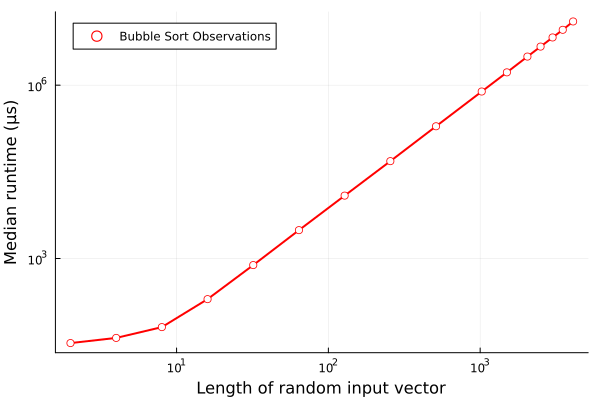

In [ ]:
let

    N = bubble_results_array[:,1]
    X = bubble_results_array[:,2];

    plot(N,X, c=:red, lw=2, label="")
    scatter!(N,X, c=:white, msc=:red, label="Bubble Sort Observations", legend=:topleft)

    Plots.xlabel!("Length of random input vector", fontsize = 18);
    Plots.ylabel!("Median runtime (μs)", fontsize = 18, yscale=:log10, xscale=:log10)
end

The plot above shows median runtime values for each array size, which gives us a nice overview of the performance scaling. But what's actually happening during a single benchmark run? Let's zoom in and examine the detailed timing distribution for a specific array size.

When we run the `@benchmark` macro on a single case, we get much more than just the median - we see the full statistical picture including minimum time, maximum time, memory allocations, and even a handy ASCII histogram. This detailed view helps us understand the variability in our measurements and gives us confidence in our median values that we plotted above.

In [ ]:
let
    
    L = 4096; # Length of the sequence to sort (you can change this).
    tmp_random_array = rand(1:L, L) |> v-> sort(v, rev=true) # Create worst-case input: reverse sorted array
    @benchmark bubblesort($tmp_random_array);
end

BenchmarkTools.Trial: 392 samples with 1 evaluation per sample.
 Range (min … max):  12.324 ms … 39.453 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     12.607 ms              ┊ GC (median):    0.00%
 Time  (mean ± σ):   12.754 ms ±  1.398 ms  ┊ GC (mean ± σ):  0.00% ± 0.00%

    ▅█▄▅▆▅▃▂▂                                                  
  ▅▇██████████▇█▆▄▇▅▄▃▄▁▁▁▃▂▃▁▃▂▁▁▁▁▁▂▁▁▂▁▃▁▂▁▂▁▁▁▁▁▁▁▁▁▂▁▁▂▂ ▃
  12.3 ms         Histogram: frequency by time        14.5 ms <

 Memory estimate: 32.06 KiB, allocs estimate: 3.

## Task 3: Benchmark the built-in Julia sort function
In this task, we will benchmark [the built-in Julia `sort(...)` function](https://docs.julialang.org/en/v1/base/sort/#Base.sort) to compare its performance to our bubble sort implementation. This will help us understand how much slower our bubble sort implementation is compared to the built-in Julia sort function.

In [ ]:
sort_results_array = let

    number_of_samples = 12;
    collection = [2^i for i ∈ 1:number_of_samples]; # This is a comprehension,

    push!(collection, 1500); # add out of sequence
    push!(collection, 2500); # add out of sequence
    push!(collection, 3000); # add out of sequence
    push!(collection, 3500); # add out of sequence
    collection |> sort! # put back in order
    
    results = Array{Any, 2}(undef, length(collection), 2);

    counter = 1;
    @showprogress dt=1 desc="Computing..." for i ∈ eachindex(collection)
        
        tmp_random_array = rand(1:collection[i] ,collection[i]) |> v->sort(v, rev=true) # Create worst-case input: reverse sorted array
        tvals = @benchmark sort($tmp_random_array);
        
        results[counter, 1] = collection[i];
        results[counter, 2] = median(tvals.times);
        counter += 1;
    end
    results;
end;

Computing... 100%|███████████████████████████████████████| Time: 0:00:39


Just like we did with bubble sort, let's take a detailed look at the timing distribution for Julia's built-in sort function. This will show us the full statistical breakdown behind the median values we're plotting, and you'll likely notice that the built-in sort has much more consistent timing behavior, a sign of a well-optimized algorithm.

In [17]:
let
    L = 4096; # you can change this!
    tmp_random_array = rand(1:L, L) |> v-> sort(v, rev=true) # Create worst-case input: reverse sorted array
    @benchmark sort($tmp_random_array);
end

BenchmarkTools.Trial: 10000 samples with 9 evaluations per sample.
 Range (min … max):  2.394 μs … 365.551 μs  ┊ GC (min … max):  0.00% … 98.31%
 Time  (median):     4.083 μs               ┊ GC (median):     0.00%
 Time  (mean ± σ):   5.061 μs ±  12.862 μs  ┊ GC (mean ± σ):  21.11% ±  9.35%

           ▅█▄                                                 
  █▇▄▃▂▂▃▅▇███▇▅▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▂▂▁▂▁▁▁▂▂▂▂ ▃
  2.39 μs         Histogram: frequency by time          12 μs <

 Memory estimate: 32.06 KiB, allocs estimate: 3.

### Visualize built-in Julia sort results
Now that we have the built-in Julia sort results array that holds the timing information for each length of random sequence, we can plot it [using functions exported by the `Plots.jl` package](https://github.com/JuliaPlots/Plots.jl).

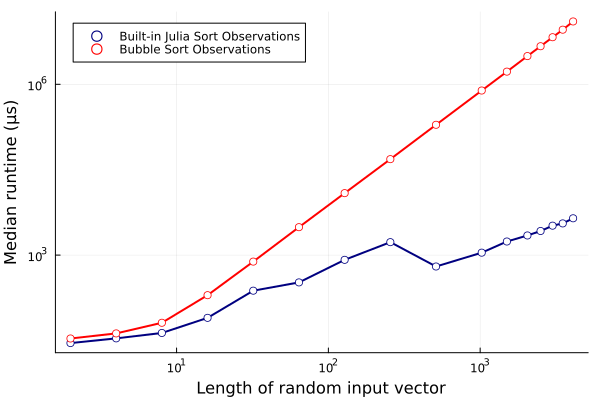

In [16]:
let

    # built-in Julia sort results -
    N = sort_results_array[:,1]
    X1 = sort_results_array[:,2];

    plot(N,X1, c=:navy, lw=2, label="")
    scatter!(N,X1, c=:white, msc=:navy, label="Built-in Julia Sort Observations")

    # our bubble sort results -
    N = bubble_results_array[:,1]
    X2 = bubble_results_array[:,2];

    plot!(N,X2, c=:red, lw=2, label="")
    scatter!(N,X2, c=:white, msc=:red, label="Bubble Sort Observations", yscale=:log10, xscale=:log10, legend=:topleft)

    Plots.xlabel!("Length of random input vector", fontsize = 18);
    Plots.ylabel!("Median runtime (μs)", fontsize = 18)
end

## Summary

Through this benchmarking exercise, we've gained hands-on experience with performance analysis and learned some important lessons about algorithm choice. Our bubble sort implementation, while correctly sorting the data, demonstrates why theoretical complexity analysis matters in practice.

The performance difference is truly staggering when you look at the actual numbers. Our bubble sort implementation runs in milliseconds (thousands of microseconds), while Julia's built-in sort function completes the same task in just microseconds. That's often a difference of 3-4 orders of magnitude! This dramatic gap illustrates why modern programming languages invest heavily in optimized algorithms. Julia's default sorting algorithm uses a sophisticated hybrid approach that combines RadixSort, ScratchQuickSort, InsertionSort, and CountingSort depending on the input type, size, and composition. This adaptive strategy achieves O(n log n) complexity instead of bubble sort's O(n²) behavior.

This brings us to an important principle in software engineering: the "buy versus build" decision. In almost all cases, it's better to "buy" (use existing, well-tested library code) rather than "build" (implement algorithms from scratch). The built-in sorting functions in languages like Julia, Python, or Java represent decades of algorithmic research, optimization work, and battle-testing across millions of use cases. Unless you have very specific requirements that existing libraries can't meet, or you're implementing something for educational purposes (like we're doing here), you should reach for the optimized library solution.

This exercise reinforces a fundamental principle in software development: correctness comes first, but performance optimization requires thoughtful algorithm selection. While our bubble sort works perfectly for small datasets, it becomes prohibitively slow as data size grows. The benchmarking tools we used here - particularly the `BenchmarkTools.jl` package - provide the foundation for making informed decisions about algorithm performance in real-world applications.

For your future projects, remember that understanding both the theoretical complexity and practical performance characteristics of algorithms will help you build more efficient and scalable solutions. And when in doubt, trust the library - those optimized implementations exist for good reasons!